# 05 — Credit Scorecard

**Input:** `data/cs_features.parquet`, `models/lr_final.pkl`, `models/scaler.pkl`, `models/scorecard_params.pkl`  
**Output:** Scorecard plots and tables in `reports/`

---

In [1]:
import os, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')
%matplotlib inline

os.makedirs('reports', exist_ok=True)

PAL = {'good':'#1D9E75','bad':'#D85A30','neutral':'#378ADD'}

df     = pd.read_parquet('data/cs_features.parquet')
X      = df.drop(columns='default')
y      = df['default']
lr     = joblib.load('models/lr_final.pkl')
scaler = joblib.load('models/scaler.pkl')
params = joblib.load('models/scorecard_params.pkl')

Factor=params['Factor']; Offset=params['Offset']
PDO=params['PDO']; BASE_SCORE=params['BASE_SCORE']; BASE_ODDS=params['BASE_ODDS']

X_scaled = scaler.transform(X)
print('Data and models loaded ✓')
print(f'PDO={PDO}  Base score={BASE_SCORE}  Base odds={BASE_ODDS}:1')

Data and models loaded ✓
PDO=20  Base score=600  Base odds=50:1


## 1. Compute Scores

In [2]:
log_odds = lr.intercept_[0] + X_scaled @ lr.coef_[0]
scores   = np.round(Offset + Factor * (-log_odds)).astype(int)
print(f'Score range: {scores.min()} – {scores.max()}')
print(f'Mean: {scores.mean():.1f}  Std: {scores.std():.1f}')
score_df = pd.DataFrame({'score':scores, 'default':y.values,
                          'default_prob':lr.predict_proba(X_scaled)[:,1]})

Score range: 43 – 2641
Mean: 510.3  Std: 40.3


## 2. Score Distribution

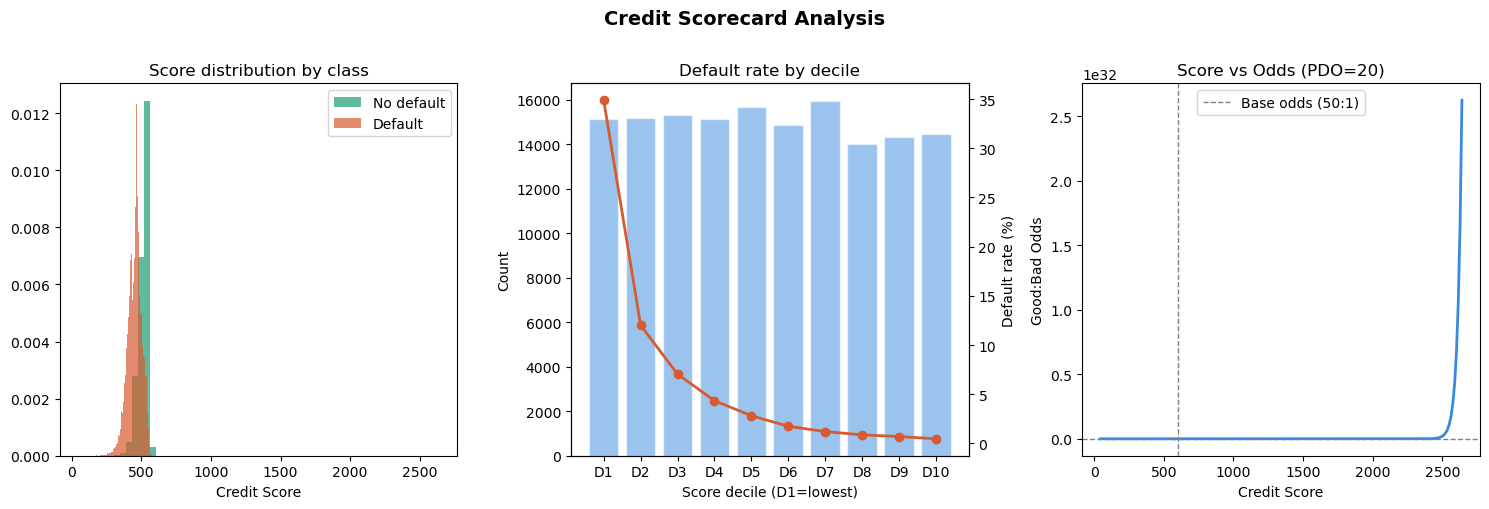

In [3]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

good_s = score_df[score_df['default']==0]['score']
bad_s  = score_df[score_df['default']==1]['score']
axes[0].hist(good_s, bins=60, color=PAL['good'], alpha=0.7, density=True, label='No default')
axes[0].hist(bad_s,  bins=60, color=PAL['bad'],  alpha=0.7, density=True, label='Default')
axes[0].set_xlabel('Credit Score'); axes[0].set_title('Score distribution by class'); axes[0].legend()

score_df['decile'] = pd.qcut(score_df['score'], q=10, labels=False, duplicates='drop')
dec = score_df.groupby('decile').agg(
    mean_score=('score','mean'), default_rate=('default','mean'), count=('default','count')
).reset_index()
dec['label'] = [f'D{i+1}' for i in range(len(dec))]
ax2 = axes[1].twinx()
axes[1].bar(dec['label'], dec['count'], color=PAL['neutral'], alpha=0.5, edgecolor='white')
ax2.plot(dec['label'], dec['default_rate']*100, 'o-', color=PAL['bad'], ms=6, lw=2)
axes[1].set_xlabel('Score decile (D1=lowest)'); axes[1].set_title('Default rate by decile')
axes[1].set_ylabel('Count'); ax2.set_ylabel('Default rate (%)')

sr = np.linspace(scores.min(), scores.max(), 200)
or_ = np.exp((sr - Offset) / Factor)
axes[2].plot(sr, or_, color=PAL['neutral'], lw=2)
axes[2].axhline(BASE_ODDS, color='gray', ls='--', lw=1, label=f'Base odds ({BASE_ODDS}:1)')
axes[2].axvline(BASE_SCORE, color='gray', ls='--', lw=1)
axes[2].set_xlabel('Credit Score'); axes[2].set_ylabel('Good:Bad Odds')
axes[2].set_title(f'Score vs Odds (PDO={PDO})'); axes[2].legend()

plt.suptitle('Credit Scorecard Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/scorecard_distribution.png', bbox_inches='tight')
plt.show()

## 3. Cutoff Analysis

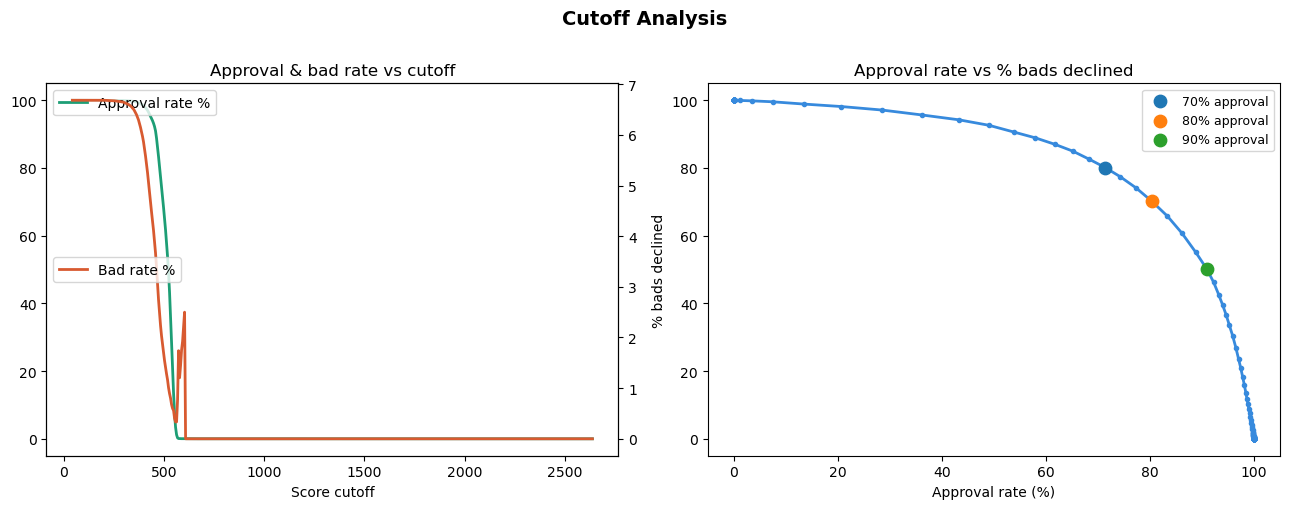

  Cutoff    Approval%   BadRate%   Bads Declined%
     493        71.4%      1.86%            80.1%
     488        74.3%      2.03%            77.4%
     478        80.4%      2.49%            70.1%
     468        86.2%      3.05%            60.7%
     458        91.0%      3.67%            50.1%


In [4]:
cutoff_stats = []
for cutoff in range(int(scores.min()), int(scores.max()), 5):
    approved = score_df[score_df['score'] >= cutoff]
    declined = score_df[score_df['score'] <  cutoff]
    if len(approved) == 0: continue
    cutoff_stats.append({'cutoff':cutoff,
        'approval_rate':     len(approved)/len(score_df)*100,
        'bad_rate_approved': approved['default'].mean()*100,
        'pct_bads_declined': declined['default'].sum()/score_df['default'].sum()*100})
cutoff_df = pd.DataFrame(cutoff_stats)

fig, axes = plt.subplots(1,2,figsize=(13,5))
ax2a = axes[0].twinx()
axes[0].plot(cutoff_df['cutoff'], cutoff_df['approval_rate'],    color=PAL['good'], lw=2, label='Approval rate %')
ax2a.plot(cutoff_df['cutoff'],    cutoff_df['bad_rate_approved'], color=PAL['bad'],  lw=2, label='Bad rate %')
axes[0].set_xlabel('Score cutoff'); axes[0].set_title('Approval & bad rate vs cutoff')
axes[0].legend(loc='upper left'); ax2a.legend(loc='center left')

axes[1].plot(cutoff_df['approval_rate'], cutoff_df['pct_bads_declined'],
              color=PAL['neutral'], lw=2, marker='o', ms=3)
for apr in [70,80,90]:
    row = cutoff_df.iloc[(cutoff_df['approval_rate']-apr).abs().argsort().iloc[0]]
    axes[1].scatter(row['approval_rate'], row['pct_bads_declined'], s=80, zorder=5, label=f'{apr}% approval')
axes[1].set_xlabel('Approval rate (%)'); axes[1].set_ylabel('% bads declined')
axes[1].set_title('Approval rate vs % bads declined'); axes[1].legend(fontsize=9)

plt.suptitle('Cutoff Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/cutoff_analysis.png', bbox_inches='tight')
plt.show()

print(f'{"Cutoff":>8} {"Approval%":>12} {"BadRate%":>10} {"Bads Declined%":>16}')
for apr in [70,75,80,85,90]:
    row = cutoff_df.iloc[(cutoff_df['approval_rate']-apr).abs().argsort().iloc[0]]
    print(f"{row['cutoff']:>8.0f} {row['approval_rate']:>11.1f}% {row['bad_rate_approved']:>9.2f}% {row['pct_bads_declined']:>15.1f}%")

## 4. Lorenz Curve & Gini

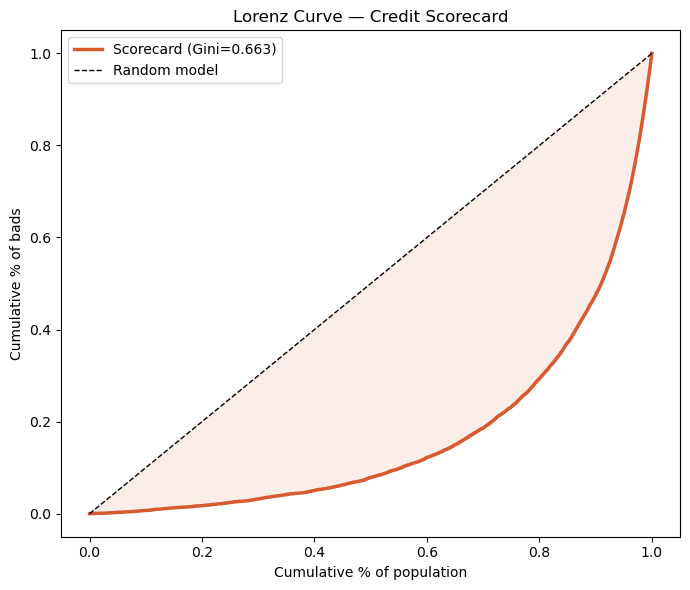

Scorecard Gini: 0.6632

=== Notebook 05 complete — run 06_monitoring.ipynb next ===


In [5]:
sdf = score_df.sort_values('score', ascending=False).reset_index(drop=True)
sdf['cum_pct_pop']  = (sdf.index+1) / len(sdf)
sdf['cum_pct_bads'] = sdf['default'].cumsum() / sdf['default'].sum()
gini_coeff = 1 - 2*np.trapz(sdf['cum_pct_bads'], sdf['cum_pct_pop'])

fig, ax = plt.subplots(figsize=(7,6))
ax.plot(sdf['cum_pct_pop'], sdf['cum_pct_bads'],
         color=PAL['bad'], lw=2.5, label=f'Scorecard (Gini={gini_coeff:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random model')
ax.fill_between(sdf['cum_pct_pop'], sdf['cum_pct_bads'], sdf['cum_pct_pop'], alpha=0.1, color=PAL['bad'])
ax.set_xlabel('Cumulative % of population')
ax.set_ylabel('Cumulative % of bads')
ax.set_title('Lorenz Curve — Credit Scorecard'); ax.legend()
plt.tight_layout()
plt.savefig('reports/lorenz_curve.png', bbox_inches='tight')
plt.show()
print(f'Scorecard Gini: {gini_coeff:.4f}')
print('\n=== Notebook 05 complete — run 06_monitoring.ipynb next ===')